In [1]:
import torch
import torch.nn as nn
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
import warnings
from tqdm import tqdm
import os
import json
from torch_geometric.data import Data, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt

# Ignore specific warnings
warnings.filterwarnings("ignore")

class MyGRU(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super(MyGRU,self).__init__()
        self.gru = nn.GRU(in_dim, hidden_dim, batch_first=True)

    def forward(self, x, batch):
        # x: [total_num_nodes, feature_dim]
        # batch: [total_num_nodes] → 图编号

        # Step 1: 按图划分节点特征
        graphs = []
        lengths = []

        num_graphs = batch.max().item() + 1
        for i in range(num_graphs):
            node_feats = x[batch == i]              # shape: [num_nodes_i, feature_dim]
           
            sorted_nodes = node_feats
            graphs.append(sorted_nodes)
            lengths.append(sorted_nodes.size(0))

        # Step 2: pad 成相同长度序列 → [batch_size, max_seq_len, feature_dim]
        padded_seqs = pad_sequence(graphs, batch_first=True)   # 自动 padding 0
        lengths = torch.tensor(lengths)

        # Step 3: pack 序列送入 GRU
        packed_input = pack_padded_sequence(padded_seqs, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, h_n = self.gru(packed_input)

        # h_n: [1, batch_size, hidden_dim] → 最后时间步的隐藏状态
        # 我们返回 squeeze 掉层数
        return h_n.squeeze(0)   # shape: [batch_size, hidden_dim]

class MultiScaleGAT(torch.nn.Module):
    def __init__(self, input_size, hidden_channels):
        super(MultiScaleGAT, self).__init__()
        self.conv1 = GATConv(input_size, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels)
        self.conv3 = GATConv(hidden_channels, hidden_channels)
        self.conv4 = GATConv(hidden_channels, hidden_channels)
        self.attention = nn.MultiheadAttention(hidden_channels, num_heads=1)

    def forward(self, x, edge_index, batch, return_attn: bool = False):
        # ---- GAT layers (需要边注意力就用 return_attention_weights=True) ----
        if return_attn:
            x1, (ei1, a1) = self.conv1(x, edge_index, return_attention_weights=True)
            x1 = x1.relu()
            x2, (ei2, a2) = self.conv2(x1, edge_index, return_attention_weights=True)
            x2 = x2.relu()
            x3, (ei3, a3) = self.conv3(x2, edge_index, return_attention_weights=True)
            x3 = x3.relu()
            x4, (ei4, a4) = self.conv4(x3, edge_index, return_attention_weights=True)
        else:
            x1 = self.conv1(x, edge_index).relu()
            x2 = self.conv2(x1, edge_index).relu()
            x3 = self.conv3(x2, edge_index).relu()
            x4 = self.conv4(x3, edge_index)

        # ---- 多尺度池化 ----
        x1_pool = global_mean_pool(x1, batch)
        x2_pool = global_mean_pool(x2, batch)
        x3_pool = global_mean_pool(x3, batch)
        x4_pool = global_mean_pool(x4, batch)
        multi_scale_features = torch.stack([x1_pool, x2_pool, x3_pool, x4_pool], dim=0)  # [4, B, C]

        # ---- self-attention (取出 attn_weights) ----
        attn_output, attn_weights = self.attention(
            multi_scale_features, multi_scale_features, multi_scale_features,
            need_weights=True, average_attn_weights=True
        )
        spatial_feature = attn_output.mean(dim=0)  # [B, C]

        if not return_attn:
            return spatial_feature

        # a*: [E, heads] or [E, 1]，这里 heads=1，后面会 squeeze
        gat_attn = {
            "layer1": (ei1, a1),
            "layer2": (ei2, a2),
            "layer3": (ei3, a3),
            "layer4": (ei4, a4),
        }
        # attn_weights: [B, tgt_len(=4), src_len(=4)]  (average_attn_weights=True)
        return spatial_feature, gat_attn, attn_weights


   
class FUSION(torch.nn.Module):
    def __init__(self, input_size, hidden_channels):
        super(FUSION, self).__init__()
        self.gat = MultiScaleGAT(input_size, hidden_channels)
        self.gru = MyGRU(input_size, hidden_channels)
        self.lin = nn.Linear(hidden_channels, 2)

    def forward(self, x, edge_index, batch, return_attn: bool = False):
        if return_attn:
            spatial_feature, gat_attn, ms_attn = self.gat(x, edge_index, batch, return_attn=True)
        else:
            spatial_feature = self.gat(x, edge_index, batch, return_attn=False)

        h_n = self.gru(x, batch)
        fusion_feature = spatial_feature + h_n
        fusion_feature = F.dropout(fusion_feature, p=0.2, training=self.training)
        out = self.lin(fusion_feature)

        if not return_attn:
            return out
        return out, gat_attn, ms_attn



In [2]:

def load_json_folder(folder_path):
    data_array = []

    # Iterate through files in the folder
    for filename in tqdm(os.listdir(folder_path)):
        file_path = os.path.join(folder_path, filename)

        # Check if the file is a JSON file
        if filename.endswith(".json"):
            # Read and load the JSON file
            with open(file_path, 'r') as json_file:
                data = json.load(json_file)

            # Append the loaded data to the array
            data_array.append(data)


    return data_array
def convert_to_one_hot(label_tensor, num_classes):
    """
    Convert a label tensor to its one-hot encoded representation.

    Args:
    - label_tensor (torch.Tensor): Tensor containing the labels.
    - num_classes (int): Number of classes.

    Returns:
    - torch.Tensor: One-hot encoded tensor.
    """
    # Initialize the one-hot encoded tensor
    one_hot_tensor = torch.zeros(len(label_tensor), num_classes)

    # Fill in the one-hot encoded tensor
    one_hot_tensor[range(len(label_tensor)), label_tensor] = 1

    return one_hot_tensor
def train(model, optimizer, criterion, loader, device):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    model.train()
    total_loss = 0
    y_true = []
    y_pred = []

    for data in loader:  # Iterate in batches over the train dataset.
        # Ensure data is on the correct device and type
        data.x = data.x.to(device, dtype=torch.float32)  # Convert to float32 and ensure on GPU
        data.edge_index = data.edge_index.to(device, dtype=torch.long)  # Ensure edge_index is long and on GPU
        data.y = data.y.to(device, dtype=torch.long)  # Ensure y is long and on GPU
        data.batch = data.batch.to(device) if data.batch is not None else None  # Handle batch index for batched graphs
        # batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
        
        # Forward pass
        out = model(data.x, data.edge_index, data.batch)  # Perform a single forward pass
        loss = criterion(out, data.y)  # Compute loss (CrossEntropyLoss expects long labels, not one-hot)
        loss.backward()  # Derive gradients
        optimizer.step()  # Update parameters based on gradients
        optimizer.zero_grad()  # Clear gradients

        # Compute predictions for metrics
        pred = out.argmax(dim=1)  # Get predicted class
        y_true.extend(data.y.cpu().tolist())  # Move to CPU for sklearn metrics
        y_pred.extend(pred.cpu().tolist())  # Move to CPU for sklearn metrics
        total_loss += loss.item()  # Accumulate loss (scale by batch size)

    # Calculate metrics
    average_loss = total_loss / len(loader)  # Average loss per graph
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return average_loss, accuracy, precision, recall, f1, model
    

def test(model, loader):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    model.eval()
    y_true = []
    y_pred = []
    correct = 0

    for data in loader:  # Iterate in batches over the training/test dataset.
        data.edge_index = data.edge_index.to(torch.long)
        data.x = data.x.to(model.parameters().__next__().dtype)
        # batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)  # Use the class with the highest probability.
        y_true.extend(data.y.tolist())
        y_pred.extend(pred.tolist())
        # correct += int((pred == data.y).sum())  # Check against ground-truth labels.

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)  # or 'micro' or 'weighted'
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    # Compute accuracy
    # accuracy = correct / len(loader.dataset)

    return accuracy, precision, recall, f1


In [3]:

# Assuming train, test, load_json_folder, and FUSION are defined elsewhere
# from your_module import train, test, load_json_folder, FUSION

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load training data
train_data = load_json_folder("data/delegatecall_train")
Train_data = []
for data in train_data:
    x = torch.tensor(data["node_feature"], dtype=torch.float64).to(device)
    inputsize = x.shape[1]
    sources = [int(num) for num in data["edge_index"][0]]
    target = [int(num) for num in data["edge_index"][1]]
    edges = torch.tensor([sources, target]).to(device)
    y = torch.tensor([data["label"]], dtype=torch.long).to(device)
    Train_data.append(Data(x=x, edge_index=edges, y=y))

# Load test data
# Test_data = []
# test_data = load_json_folder("data/delegatecall_test")
# for data in test_data:
#     x = torch.tensor(data["node_feature"], dtype=torch.float64).to(device)
#     sources = [int(num) for num in data["edge_index"][0]]
#     target = [int(num) for num in data["edge_index"][1]]
#     edges = torch.tensor([sources, target]).to(device)
#     y = torch.tensor([data["label"]], dtype=torch.long).to(device)
#     Test_data.append(Data(x=x, edge_index=edges, y=y))

# # Create DataLoader instances
# train_loader = DataLoader(Train_data, batch_size=32, shuffle=True)
# test_loader = DataLoader(Test_data, batch_size=32, shuffle=False)

# # Initialize model, criterion, and optimizer
# model = FUSION(hidden_channels=64, input_size=inputsize).to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # Early stopping parameters
# patience = 5  # Number of epochs to wait for improvement
# best_accuracy = 0.0
# epochs_no_improve = 0
# best_model_path = 'model/delegatecall_model_best.pth'

# Training and testing loop
# for epoch in range(200):
#     # Training
#     model.train()
#     train_loss, train_accuracy, train_precision, train_recall, train_f1, model = train(model, optimizer, criterion, train_loader, device)

#     # Testing
#     model.eval()
#     test_accuracy, test_precision, test_recall, test_f1 = test(model, test_loader)

#     # Print progress every 10 epochs
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f} | "
#               f"Train Precision: {train_precision:.4f} | Train Recall: {train_recall:.4f} | Train F1: {train_f1:.4f}")
#         print(f"Test Accuracy: {test_accuracy:.4f} | Test Precision: {test_precision:.4f} | "
#               f"Test Recall: {test_recall:.4f} | Test F1: {test_f1:.4f}")

#     # Early stopping logic
#     if test_accuracy > best_accuracy:
#         best_accuracy = test_accuracy
#         epochs_no_improve = 0
#         # Save the best model
#         torch.save(model.state_dict(), best_model_path)
#         print(f"New best test accuracy: {best_accuracy:.4f}, model saved to {best_model_path}")
#     else:
#         epochs_no_improve += 1
        # print(f"No improvement in test accuracy. Epochs without improvement: {epochs_no_improve}")

    # # Check for early stopping
    # if epochs_no_improve >= patience:
    #     # print(f"Early stopping triggered after {epoch + 1} epochs. No improvement in test accuracy for {patience} epochs.")
    #     break

# Load and evaluate the best model
# model.load_state_dict(torch.load(best_model_path, map_location=device))
# model.eval()
# final_accuracy, final_precision, final_recall, final_f1 = test(model, test_loader)
# print(f"Final Best Model | Accuracy: {final_accuracy:.4f} | Precision: {final_precision:.4f} | "
#       f"Recall: {final_recall:.4f} | F1 Score: {final_f1:.4f}")
# print(f"Best model saved at: {best_model_path}")

Using device: cuda


100%|██████████| 139/139 [00:03<00:00, 44.13it/s]


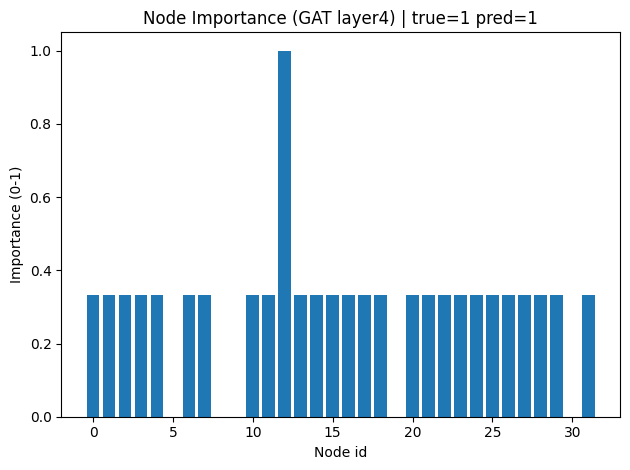

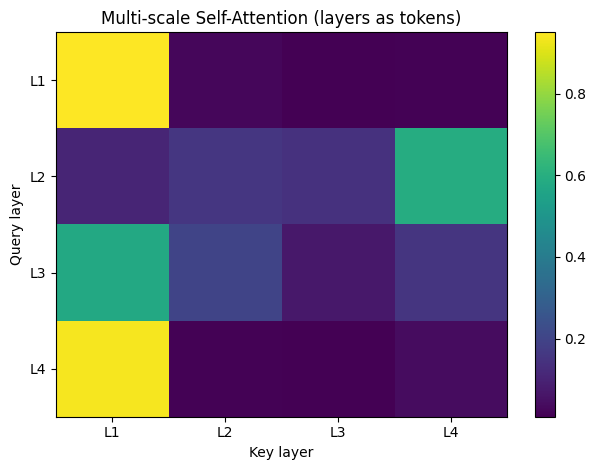

Top important nodes: [12, 23, 0, 17, 18, 20, 21, 22, 29, 28]


In [6]:
def edge_attn_to_node_score(edge_index, alpha, num_nodes: int, reduce: str = "sum"):
    """
    edge_index: [2, E]
    alpha: [E, 1] or [E]
    返回: node_score [num_nodes]
    """
    if alpha.dim() == 2:
        alpha = alpha.squeeze(-1)  # [E]

    src, dst = edge_index[0], edge_index[1]
    node_score = torch.zeros(num_nodes, device=alpha.device)

    if reduce == "sum":
        node_score.index_add_(0, dst, alpha)
    elif reduce == "mean":
        node_score.index_add_(0, dst, alpha)
        deg = torch.zeros(num_nodes, device=alpha.device)
        deg.index_add_(0, dst, torch.ones_like(alpha))
        node_score = node_score / (deg + 1e-9)
    else:
        raise ValueError("reduce must be sum or mean")

    # 归一化到 0~1，便于画热力图
    node_score = (node_score - node_score.min()) / (node_score.max() - node_score.min() + 1e-12)
    return node_score


def load_one_json_as_data(json_path, device):
    with open(json_path, "r") as f:
        d = json.load(f)

    x = torch.tensor(d["node_feature"], dtype=torch.float32, device=device)
    src = torch.tensor([int(i) for i in d["edge_index"][0]], dtype=torch.long, device=device)
    dst = torch.tensor([int(i) for i in d["edge_index"][1]], dtype=torch.long, device=device)
    edge_index = torch.stack([src, dst], dim=0)

    # 单图 batch 全 0
    batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
    y = torch.tensor([d["label"]], dtype=torch.long, device=device)
    return x, edge_index, batch, y

@torch.no_grad()
def explain_one_case(model, json_path, device, which_gat_layer="layer4", reduce="sum"):
    model.eval()
    x, edge_index, batch, y = load_one_json_as_data(json_path, device)

    out, gat_attn, ms_attn = model(x, edge_index, batch, return_attn=True)
    pred = out.argmax(dim=1).item()

    # ---- 1) 节点热力图：选一层（比如 layer4 更偏“长路径”语义） ----
    ei, alpha = gat_attn[which_gat_layer]
    node_score = edge_attn_to_node_score(ei, alpha, num_nodes=x.size(0), reduce=reduce).detach().cpu()

    plt.figure()
    plt.title(f"Node Importance (GAT {which_gat_layer}) | true={y.item()} pred={pred}")
    plt.xlabel("Node id")
    plt.ylabel("Importance (0-1)")
    plt.bar(range(len(node_score)), node_score.numpy())
    plt.tight_layout()
    plt.savefig(
    "node_heatmap_delegatecall_case.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

    # ---- 2) 多尺度 self-attn：4x4 heatmap ----
    # ms_attn: [B, 4, 4]，单样本 B=1
    A = ms_attn[0].detach().cpu().numpy()

    plt.figure()
    plt.title("Multi-scale Self-Attention (layers as tokens)")
    plt.xlabel("Key layer")
    plt.ylabel("Query layer")
    plt.imshow(A, aspect="auto")
    plt.colorbar()
    plt.xticks([0,1,2,3], ["L1","L2","L3","L4"])
    plt.yticks([0,1,2,3], ["L1","L2","L3","L4"])
    plt.tight_layout()
    plt.savefig(
    "multiscale_attention_delegatecall_case.png",
    dpi=300,
    bbox_inches="tight"
)
    plt.show()

    # 返回 top-k 节点方便你后续做“路径 case study”
    topk = torch.topk(torch.tensor(node_score), k=min(10, len(node_score))).indices.tolist()
    return pred, node_score, topk

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FUSION(hidden_channels=64, input_size=inputsize).to(device)
model.load_state_dict(torch.load("model/delegatecall_model_best.pth", map_location=device))

pred, node_score, topk = explain_one_case(
    model,
    json_path="data/delegatecall_test/1_50007.dot.json",
    device=device,
    which_gat_layer="layer4",
    reduce="sum"
)
print("Top important nodes:", topk)

